# Name: James McGinty
## Date: 4/8/25
### Exercise: Project #2, Part 2: Web Scraped Data Analysis and Visualizations
### Purpose: Scrape data from a website and answer analysis questions

Importing all necessary libraries

In [66]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO

Creating a list of all the urls that will be scraped

In [68]:
urls = [
    'https://www.pro-football-reference.com/years/2020/',
    'https://www.pro-football-reference.com/years/2021/',
    'https://www.pro-football-reference.com/years/2022/',
    'https://www.pro-football-reference.com/years/2023/',
    'https://www.pro-football-reference.com/years/2024/',
]

## Scrapping
Function to scrape data from a URL. First, it finds tables inside comments and then it cleans the dataframe. The function is called to scrape the data from all URLs and combine them into a single dataframe. Finally, it checks the combined dataframe to make sure it properly scraped the data.

In [79]:
def scrape_data(url):
    print(f"Scraping {url}...")
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')

    comments = soup.find_all(string=lambda text: isinstance(text, Comment))
    for comment in comments:
        if 'team_stats' in comment:
            comment_soup = BeautifulSoup(comment, 'html.parser')
            tables = pd.read_html(StringIO(str(comment_soup)))
            df = tables[0]
            break
    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [' '.join(col).strip() for col in df.columns.values]
    else:
        df.columns = [col.strip() for col in df.columns]

    year = int(url.split('/')[-2])
    df['Year'] = year

    return df

all_data = pd.concat([scrape_data(url) for url in urls], ignore_index=True)

print(all_data.head())

Scraping https://www.pro-football-reference.com/years/2020/...
Scraping https://www.pro-football-reference.com/years/2021/...
Scraping https://www.pro-football-reference.com/years/2022/...
Scraping https://www.pro-football-reference.com/years/2023/...
Scraping https://www.pro-football-reference.com/years/2024/...
   Unnamed: 0_level_0 Rk Unnamed: 1_level_0 Tm  Unnamed: 2_level_0 G  \
0                    1.0     Green Bay Packers                  16.0   
1                    2.0         Buffalo Bills                  16.0   
2                    3.0  Tampa Bay Buccaneers                  16.0   
3                    4.0      Tennessee Titans                  16.0   
4                    5.0    New Orleans Saints                  16.0   

   Unnamed: 3_level_0 PF  Unnamed: 4_level_0 Yds  Tot Yds & TO Ply  \
0                  509.0                  6224.0             990.0   
1                  501.0                  6343.0            1034.0   
2                  492.0                  

## Cleaning
Cleans and normalize column names by removing 'Unnamed: X_level_0 ' and symbols like & or %. It also replaces the symobols with the actual word. It then handles missing values by removing rows that don't include a team value. Finally, it prints the cleaned data

In [80]:
all_data.columns = (
    all_data.columns
    .str.replace(r'^Unnamed: \d+_level_0 ', '', regex=True)
    .str.replace('&', 'and')
    .str.replace('%', 'Percent')
    .str.replace('/', ' per ')
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

all_data = all_data.dropna(subset=['Tm'])
all_data = all_data[all_data['Tm'] != 'Tm']

print(all_data.head())

    Rk                    Tm     G     PF     Yds  Tot Yds and TO Ply  \
0  1.0     Green Bay Packers  16.0  509.0  6224.0               990.0   
1  2.0         Buffalo Bills  16.0  501.0  6343.0              1034.0   
2  3.0  Tampa Bay Buccaneers  16.0  492.0  6145.0              1017.0   
3  4.0      Tennessee Titans  16.0  491.0  6343.0              1031.0   
4  5.0    New Orleans Saints  16.0  482.0  6023.0              1045.0   

   Tot Yds and TO Y per P  Tot Yds and TO TO    FL   1stD  ...  Rushing TD  \
0                     6.3               11.0   6.0  358.0  ...        16.0   
1                     6.1               22.0  11.0  397.0  ...        16.0   
2                     6.0               17.0   5.0  364.0  ...        16.0   
3                     6.2               12.0   5.0  381.0  ...        26.0   
4                     5.8               17.0   9.0  367.0  ...        30.0   

   Rushing Y per A  Rushing 1stD  Penalties Pen  Penalties Yds  \
0              4.8        

## Question 1: What is the average points scored per year?
This code calculates the average points per year and then prints the table by year. It then plots the data with the years on the x-axis and the points on the y-axis

Average Points Scored per Year:
 Year
2020    737.297143
2021    726.220000
2022    688.928571
2023    687.882857
2024    724.011429
Name: PF, dtype: float64


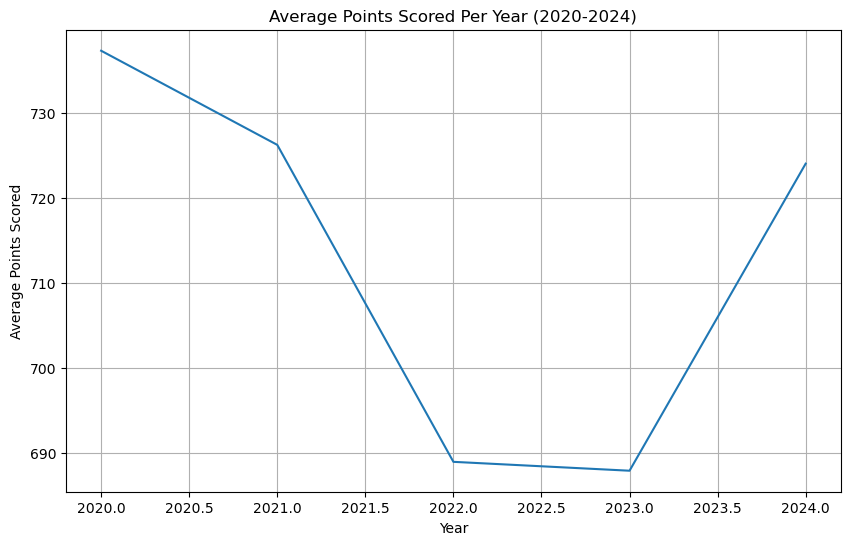

In [84]:
avg_pf_per_year = all_data.groupby('Year')['PF'].mean()
print("Average Points Scored per Year:\n", avg_pf_per_year)

plt.figure(figsize=(10, 6))
sns.lineplot(x=avg_pf_per_year.index, y=avg_pf_per_year.values)
plt.title('Average Points Scored Per Year (2020-2024)')
plt.xlabel('Year')
plt.ylabel('Average Points Scored')
plt.grid(True)
plt.show()

## Question 2: Which team scored the most points in each year?
The code first removes the rows where the team is 'League Total'. Then it searches the data to determine which team scored the most points each year. Finally, it prints a table with the teams and the number points scored by year.

In [88]:
all_data = all_data[all_data['Tm'] != 'League Total']

top_scorers = all_data.loc[all_data.groupby('Year')['PF'].idxmax(), ['Year', 'Tm', 'PF']]
print("Top Scoring Teams per Year:\n", top_scorers)

Top Scoring Teams per Year:
      Year                  Tm     PF
0    2020   Green Bay Packers  509.0
35   2021      Dallas Cowboys  530.0
70   2022  Kansas City Chiefs  496.0
105  2023      Dallas Cowboys  509.0
140  2024       Detroit Lions  564.0


## Question 3: What is the correlation between penalties and points scored?
The code removes the averages to prevent the data from being skewed. Then, the code plots the data on a scatter plot with each color representing a different year. The x-axis is the the number of penalties against the team and the y-axis is the points scored by the team.

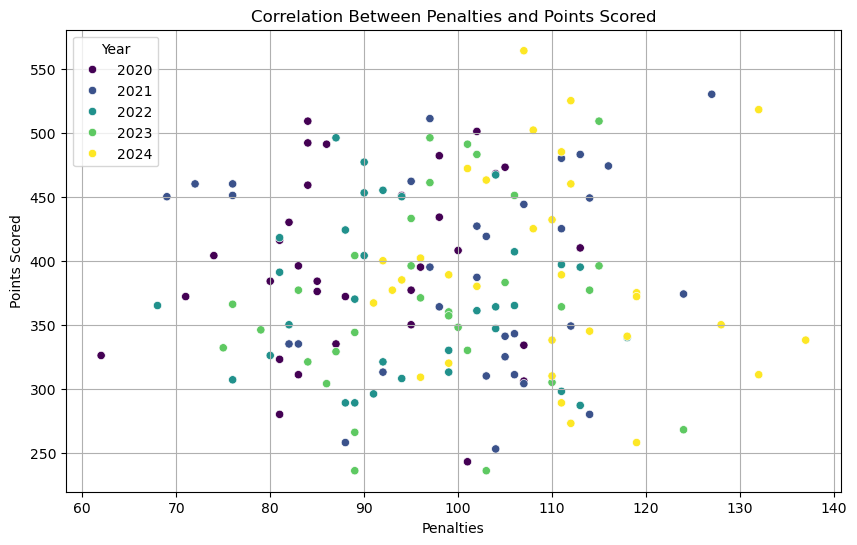

In [91]:
all_data = all_data[all_data['Tm'] != 'Avg Tm/G']
all_data = all_data[all_data['Tm'] != 'Avg Team']
plt.figure(figsize=(10, 6))
sns.scatterplot(data=all_data, x='Penalties Pen', y='PF', hue='Year', palette='viridis')
plt.title('Correlation Between Penalties and Points Scored')
plt.xlabel('Penalties')
plt.ylabel('Points Scored')
plt.legend(title='Year')
plt.grid(True)
plt.show()

## Question 4: How has total yardage changed over the years?
This code calculates the the total yardage for each year and displays it in a table. Then, it plot the data on a line plot with the years on the x-axis and the yardage on the y-axis.

Total Yardage per Year:
 Year
2020    183825.0
2021    186897.0
2022    184332.0
2023    180382.0
2024    183558.0
Name: Yds, dtype: float64


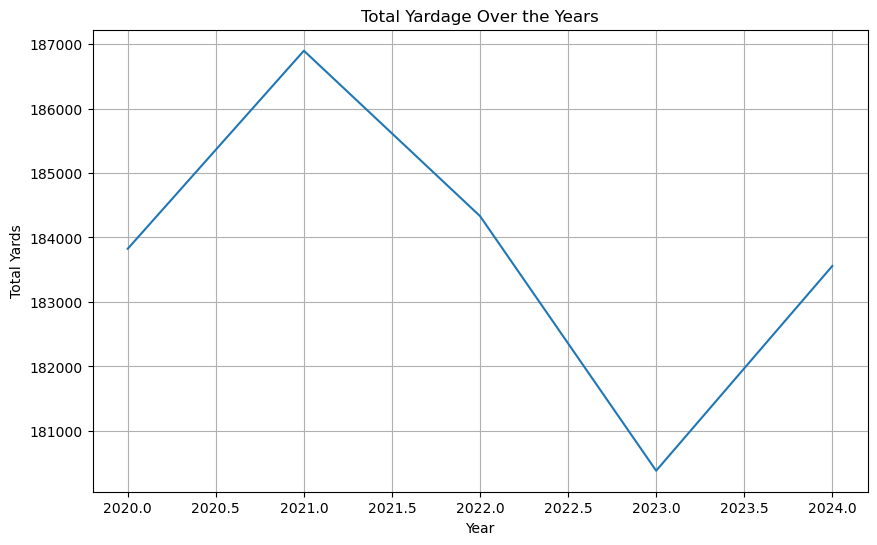

In [100]:
total_yards_per_year = all_data.groupby('Year')['Yds'].sum()
print("Total Yardage per Year:\n", total_yards_per_year)

plt.figure(figsize=(10, 6))
sns.lineplot(x=total_yards_per_year.index, y=total_yards_per_year.values)
plt.title('Total Yardage Over the Years')
plt.xlabel('Year')
plt.ylabel('Total Yards')
plt.grid(True)
plt.show()

## Question 5: Which team scored the most points per game over the past 5 seasons?
The code calculates the points per game for each team over the years. Then, it the teams that scored the most points per game each year in a table.

In [99]:
all_data['PPG'] = all_data['PF'] / all_data['G']
top_ppg = all_data.loc[all_data.groupby('Year')['PPG'].idxmax(), ['Year', 'Tm', 'PPG']]
print("Top scoring teams (points per game):\n", top_ppg)

Top scoring teams (points per game):
      Year                  Tm        PPG
0    2020   Green Bay Packers  31.812500
35   2021      Dallas Cowboys  31.176471
70   2022  Kansas City Chiefs  29.176471
105  2023      Dallas Cowboys  29.941176
140  2024       Detroit Lions  33.176471
